# Experiment 2: Long-Sequence Scaling Analysis

This notebook analyzes the ICL performance of standard Transformer and CompressiveTransformer models across different sequence lengths (128-2048 tokens).

## Objectives
- Compare ICL performance stability across sequence lengths (128, 256, 512, 1024, 2048)
- Compare standard Transformer vs CompressiveTransformer at each sequence length
- Analyze how sequence length affects model performance
- **Default: Analysis focuses on `standard` evaluation strategy only**
- **Optional: Can analyze other evaluation strategies if enabled**


In [1]:
import json
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
from collections import defaultdict
import yaml
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
sns.set_palette("husl")

# Experiment configuration
SEQUENCE_LENGTHS = [128, 256, 512, 1024, 2048]
MODEL_TYPES = ['transformer', 'compressive']
OUTPUTS_DIR = (Path("..") / "outputs").resolve()

# Analysis configuration
# Set to True to analyze other evaluation strategies in addition to 'standard'
ANALYZE_OTHER_STRATEGIES = False  # Default: False (only analyze 'standard' strategy)
DEFAULT_STRATEGY = 'standard'  # Default strategy for main analysis

print("Experiment 2: Long-Sequence Scaling Analysis")
print("=" * 60)
print(f"Sequence lengths to analyze: {SEQUENCE_LENGTHS}")
print(f"Model types: {MODEL_TYPES}")
print(f"Outputs directory: {OUTPUTS_DIR.absolute()}")
print(f"\nAnalysis Configuration:")
print(f"  Default strategy: {DEFAULT_STRATEGY}")
print(f"  Analyze other strategies: {ANALYZE_OTHER_STRATEGIES}")


Experiment 2: Long-Sequence Scaling Analysis
Sequence lengths to analyze: [128, 256, 512, 1024, 2048]
Model types: ['transformer', 'compressive']
Outputs directory: /accounts/grad/xi_cheng1017/CS282_Final_Project/outputs

Analysis Configuration:
  Default strategy: standard
  Analyze other strategies: False


## 1. Data Loading and Discovery


In [2]:
def extract_model_info(run_dir):
    """
    Flexible parser for run directory names.
    Supports:
      id_comp_seq128_xxx
      id_seq128_xxx
    """
    name = run_dir.name

    if not name.startswith("id_"):
        return None, None, None

    run_id = name.replace("id_", "", 1)
    parts = run_id.split("_")

    # Case 1: comp models -> comp / seq128 / timestamp
    if parts[0] == "comp" and parts[1].startswith("seq"):
        model_type = "CompressiveTransformer"
        seq_len = int(parts[1][3:])
        return model_type, seq_len, run_id

    # Case 2: normal transformers -> seq128 / timestamp
    if parts[0].startswith("seq"):
        model_type = "Transformer"
        seq_len = int(parts[0][3:])
        return model_type, seq_len, run_id

    return None, None, None



def load_run_data(run_dir):
    """Load metrics and config from a run directory."""
    metrics_file = run_dir / "metrics.json"
    config_file = run_dir / "config.yaml"
    
    data = {
        'metrics': None,
        'config': None,
        'has_metrics': False,
        'has_config': False
    }
    
    if metrics_file.exists():
        try:
            with open(metrics_file, 'r') as f:
                data['metrics'] = json.load(f)
                data['has_metrics'] = True
        except Exception as e:
            print(f"Warning: Failed to load metrics from {run_dir.name}: {e}")
    
    if config_file.exists():
        try:
            with open(config_file, 'r') as f:
                data['config'] = yaml.safe_load(f)
                data['has_config'] = True
        except Exception as e:
            print(f"Warning: Failed to load config from {run_dir.name}: {e}")
    
    return data

# Discover all experiment runs
all_runs = {}
if OUTPUTS_DIR.exists():

    for item in OUTPUTS_DIR.iterdir():
        
        if item.is_dir() and item.name.startswith("id_"):
            model_type, seq_len, run_id = extract_model_info(item)
            if model_type and seq_len:
                key = (model_type, seq_len)
                if key not in all_runs:
                    all_runs[key] = []
                run_data = load_run_data(item)
                all_runs[key].append({
                    'run_id': run_id,
                    'run_dir': item,
                    **run_data
                })

print(f"\nFound {len(all_runs)} unique experiment configurations")
print("\nAvailable experiments:")
print("-" * 60)
for (model_type, seq_len), runs in sorted(all_runs.items()):
    has_data = any(r['has_metrics'] for r in runs)
    status = "✓" if has_data else "✗"
    print(f"{status} {model_type:15s} seq={seq_len:4d}: {len(runs)} run(s)")



Found 10 unique experiment configurations

Available experiments:
------------------------------------------------------------
✓ CompressiveTransformer seq= 128: 1 run(s)
✓ CompressiveTransformer seq= 256: 1 run(s)
✓ CompressiveTransformer seq= 512: 1 run(s)
✓ CompressiveTransformer seq=1024: 1 run(s)
✓ CompressiveTransformer seq=2048: 1 run(s)
✓ Transformer     seq= 128: 1 run(s)
✓ Transformer     seq= 256: 1 run(s)
✓ Transformer     seq= 512: 1 run(s)
✓ Transformer     seq=1024: 1 run(s)
✓ Transformer     seq=2048: 1 run(s)


## 2. Extract Performance Metrics


In [3]:
def get_strategy_losses(metrics_data, strategy='standard'):
    """Extract loss values for a given evaluation strategy."""
    if not metrics_data or strategy not in metrics_data:
        return None
    
    strategy_data = metrics_data[strategy]
    if not strategy_data:
        return None
    
    # Get the first (and usually only) model's metrics
    model_name = list(strategy_data.keys())[0]
    model_metrics = strategy_data[model_name]
    
    if 'mean' in model_metrics:
        return np.array(model_metrics['mean'])
    return None

def compute_performance_metrics(metrics_data, strategy='standard', include_other_strategies=False, n_dims=10):
    """
    Compute various performance metrics from metrics data.
    
    Args:
        metrics_data: Dictionary containing metrics for different strategies
        strategy: Strategy to use for main analysis (default: 'standard')
        include_other_strategies: If True, also extract metrics for other strategies
        n_dims: Number of dimensions for normalization (default: 10)
    """
    if not metrics_data:
        return None
    
    # Get losses for the specified strategy (default: 'standard')
    losses = get_strategy_losses(metrics_data, strategy)
    if losses is None or len(losses) == 0:
        return None
    
    # Normalize losses by n_dims
    normalized_losses = losses / n_dims
    
    # Sequence length is len(losses) * 2 because each point is a pair (x, y)
    sequence_length = len(losses) * 2
    
    metrics = {
        'mean_loss': np.mean(normalized_losses),
        'std_loss': np.std(normalized_losses),
        'min_loss': np.min(normalized_losses),
        'max_loss': np.max(normalized_losses),
        'first_quarter_mean': np.mean(normalized_losses[:len(normalized_losses)//4]),
        'middle_half_mean': np.mean(normalized_losses[len(normalized_losses)//4:3*len(normalized_losses)//4]),
        'last_quarter_mean': np.mean(normalized_losses[3*len(normalized_losses)//4:]),
        'position_0_loss': normalized_losses[0],
        'last_position_loss': normalized_losses[-1],
        'all_losses': normalized_losses,
        'sequence_length': sequence_length,  # n_points * 2
        'n_points': len(losses),  # Keep original n_points for reference
        'strategy': strategy  # Record which strategy was used
    }
    
    # Optionally add metrics for other strategies
    if include_other_strategies:
        strategy_names = ['random_quadrants', 'orthogonal_train_test', 'overlapping_train_test', 
                         'half_subspace', 'skewed']
        for other_strategy in strategy_names:
            if other_strategy != strategy:  # Don't duplicate the main strategy
                strategy_losses = get_strategy_losses(metrics_data, other_strategy)
                if strategy_losses is not None:
                    metrics[f'{other_strategy}_mean'] = np.mean(strategy_losses / n_dims)
    
    return metrics

# Extract performance data for all runs
# Using DEFAULT_STRATEGY (default: 'standard') for main analysis
performance_data = []

for (model_type, seq_len), runs in all_runs.items():
    # Use the run with metrics if available
    selected_run = None
    for run in runs:
        if run['has_metrics']:
            selected_run = run
            break
    
    if selected_run and selected_run['has_metrics']:
        # Get n_dims from config if available
        n_dims = 10  # default
        if selected_run['has_config'] and selected_run['config']:
            n_dims = selected_run['config'].get('model', {}).get('n_dims', 10)
        
        metrics = compute_performance_metrics(
            selected_run['metrics'], 
            strategy=DEFAULT_STRATEGY,
            include_other_strategies=ANALYZE_OTHER_STRATEGIES,
            n_dims=n_dims
        )
        if metrics:
            # Use computed sequence_length from metrics (n_points * 2) instead of seq_len from directory name
            performance_data.append({
                'model_type': model_type,
                'sequence_length': metrics['sequence_length'],  # Use computed sequence_length (n_points * 2)
                'run_id': selected_run['run_id'],
                'n_dims': n_dims,  # Store n_dims for reference
                **metrics
            })

# Create DataFrame
df_performance = pd.DataFrame(performance_data)

if len(df_performance) > 0:
    print(f"\nLoaded performance data for {len(df_performance)} experiments")
    print(f"Analysis strategy: {DEFAULT_STRATEGY}")
    print("Note: Loss values are normalized by n_dims (loss/n_dims)")
    print("Note: Sequence length = n_points * 2 (each point is a pair x,y)")
    print("\nPerformance Summary:")
    print("-" * 80)
    print(df_performance[['model_type', 'sequence_length', 'n_points', 'mean_loss', 'std_loss']].to_string(index=False))
else:
    print("\nNo performance data found. Please ensure experiments have been run and evaluated.")



Loaded performance data for 10 experiments
Analysis strategy: standard
Note: Loss values are normalized by n_dims (loss/n_dims)
Note: Sequence length = n_points * 2 (each point is a pair x,y)

Performance Summary:
--------------------------------------------------------------------------------
            model_type  sequence_length  n_points  mean_loss  std_loss
           Transformer              256       128   0.082376  0.176483
           Transformer             2048      1024   0.021761  0.071148
           Transformer              128        64   0.145942  0.225578
CompressiveTransformer              128        64   0.139075  0.234348
CompressiveTransformer              512       256   0.049716  0.131632
           Transformer             1024       512   0.029849  0.093451
CompressiveTransformer              256       128   0.076044  0.175287
CompressiveTransformer             2048      1024   0.033117  0.069735
           Transformer              512       256   0.046604  0.1

## 3. Sequence Length Scaling Analysis


Available model types in data: ['Transformer' 'CompressiveTransformer']
Data shape: (10, 16)
Analysis strategy: standard

Data preview:
               model_type  sequence_length  mean_loss
0             Transformer              256   0.082376
1             Transformer             2048   0.021761
2             Transformer              128   0.145942
3  CompressiveTransformer              128   0.139075
4  CompressiveTransformer              512   0.049716
5             Transformer             1024   0.029849
6  CompressiveTransformer              256   0.076044
7  CompressiveTransformer             2048   0.033117
8             Transformer              512   0.046604
9  CompressiveTransformer             1024   0.045179


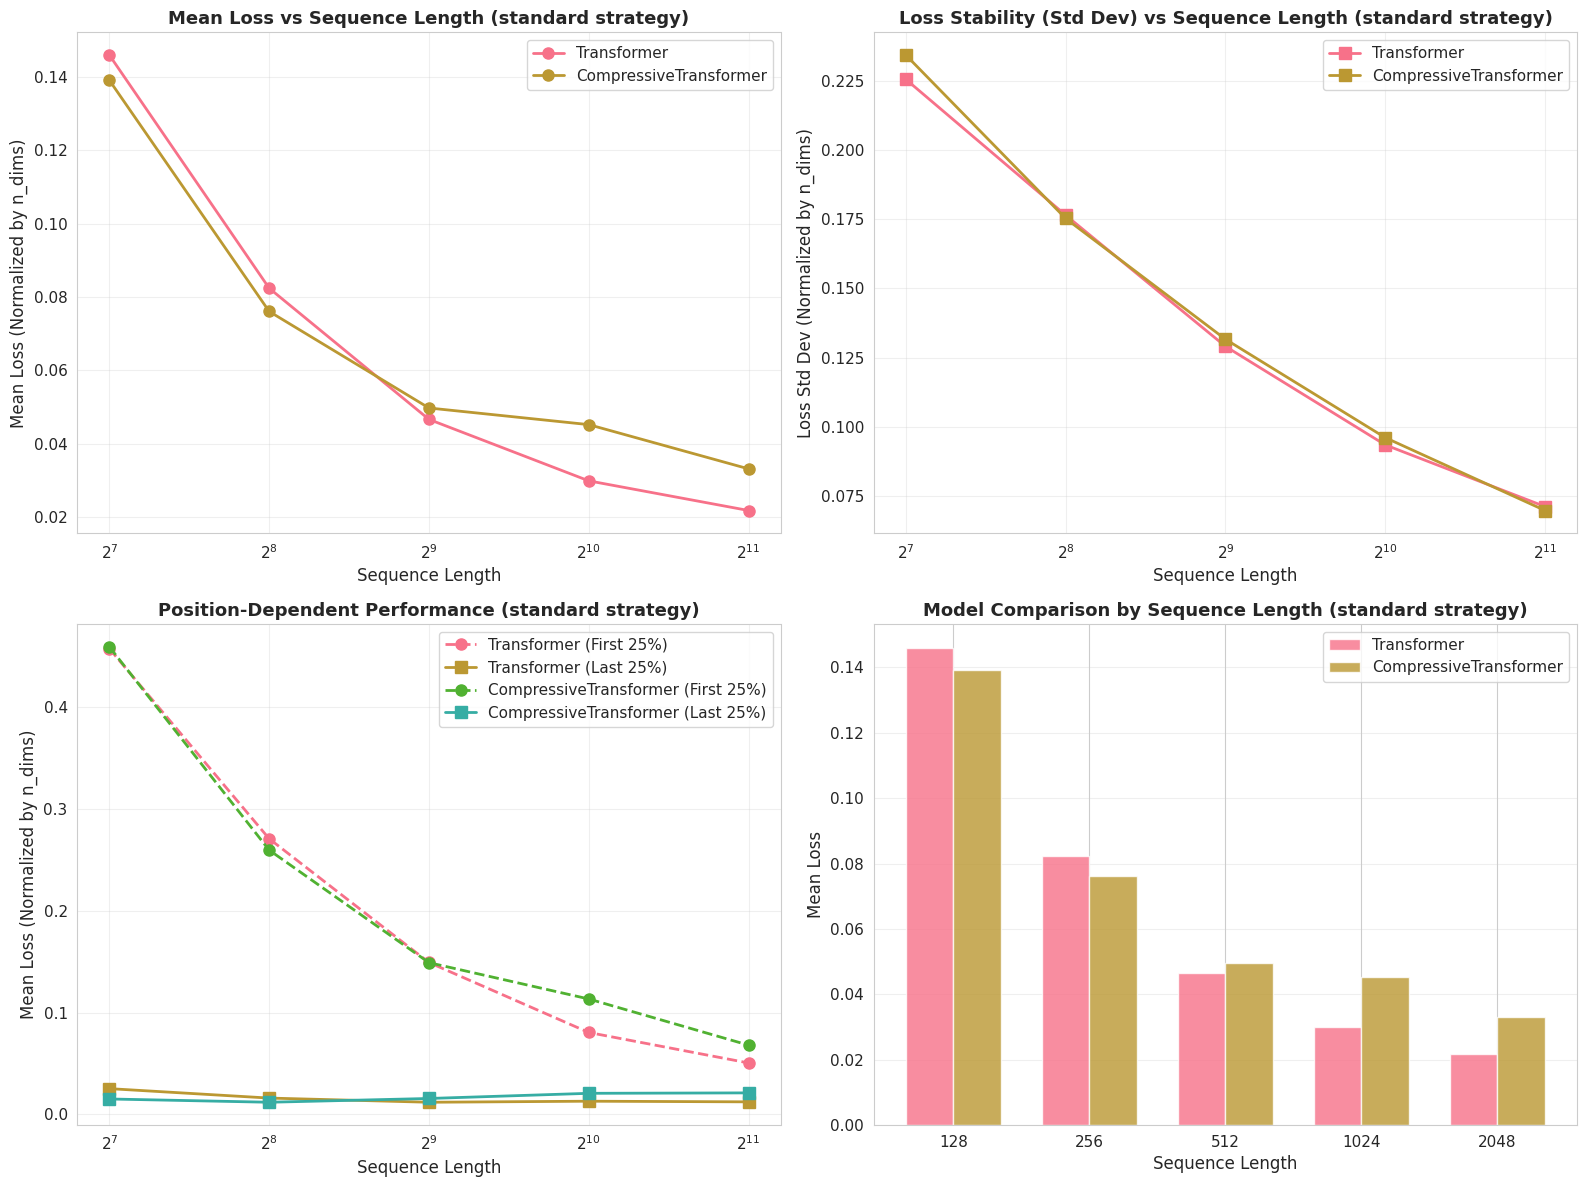

In [4]:
if len(df_performance) > 0:
    # Get actual model types from the data
    actual_model_types = df_performance['model_type'].unique()
    print(f"Available model types in data: {actual_model_types}")
    print(f"Data shape: {df_performance.shape}")
    print(f"Analysis strategy: {DEFAULT_STRATEGY}")
    print(f"\nData preview:")
    print(df_performance[['model_type', 'sequence_length', 'mean_loss']])
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Mean loss vs sequence length
    ax1 = axes[0, 0]
    for model_type in actual_model_types:
        model_data = df_performance[df_performance['model_type'] == model_type]
        if len(model_data) > 0:
            model_data = model_data.sort_values('sequence_length')
            ax1.plot(model_data['sequence_length'], model_data['mean_loss'], 
                    marker='o', linewidth=2, markersize=8, label=model_type)
    ax1.set_xlabel('Sequence Length', fontsize=12)
    ax1.set_ylabel('Mean Loss (Normalized by n_dims)', fontsize=12)
    ax1.set_title(f'Mean Loss vs Sequence Length ({DEFAULT_STRATEGY} strategy)', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log', base=2)
    
    # Plot 2: Loss stability (std) vs sequence length
    ax2 = axes[0, 1]
    for model_type in actual_model_types:
        model_data = df_performance[df_performance['model_type'] == model_type]
        if len(model_data) > 0:
            model_data = model_data.sort_values('sequence_length')
            ax2.plot(model_data['sequence_length'], model_data['std_loss'], 
                    marker='s', linewidth=2, markersize=8, label=model_type)
    ax2.set_xlabel('Sequence Length', fontsize=12)
    ax2.set_ylabel('Loss Std Dev (Normalized by n_dims)', fontsize=12)
    ax2.set_title(f'Loss Stability (Std Dev) vs Sequence Length ({DEFAULT_STRATEGY} strategy)', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log', base=2)
    
    # Plot 3: Position-dependent performance (first vs last quarter)
    ax3 = axes[1, 0]
    for model_type in actual_model_types:
        model_data = df_performance[df_performance['model_type'] == model_type]
        if len(model_data) > 0:
            model_data = model_data.sort_values('sequence_length')
            ax3.plot(model_data['sequence_length'], model_data['first_quarter_mean'], 
                    marker='o', linewidth=2, markersize=8, label=f'{model_type} (First 25%)', linestyle='--')
            ax3.plot(model_data['sequence_length'], model_data['last_quarter_mean'], 
                    marker='s', linewidth=2, markersize=8, label=f'{model_type} (Last 25%)', linestyle='-')
    ax3.set_xlabel('Sequence Length', fontsize=12)
    ax3.set_ylabel('Mean Loss (Normalized by n_dims)', fontsize=12)
    ax3.set_title(f'Position-Dependent Performance ({DEFAULT_STRATEGY} strategy)', fontsize=13, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_xscale('log', base=2)
    
    # Plot 4: Comparison bar chart
    ax4 = axes[1, 1]
    comparison_data = []
    for seq_len in SEQUENCE_LENGTHS:
        for model_type in actual_model_types:
            model_data = df_performance[
                (df_performance['model_type'] == model_type) & 
                (df_performance['sequence_length'] == seq_len)
            ]
            if len(model_data) > 0:
                comparison_data.append({
                    'Sequence Length': seq_len,
                    'Model': model_type,
                    'Mean Loss': model_data.iloc[0]['mean_loss']
                })
    
    if comparison_data:
        df_comp = pd.DataFrame(comparison_data)
        x = np.arange(len(SEQUENCE_LENGTHS))
        width = 0.35
        
        trans_losses = []
        comp_losses = []
        
        for seq_len in SEQUENCE_LENGTHS:
            # Match actual model type names
            trans_data = df_comp[(df_comp['Model'] == 'Transformer') & (df_comp['Sequence Length'] == seq_len)]
            comp_data = df_comp[(df_comp['Model'] == 'CompressiveTransformer') & (df_comp['Sequence Length'] == seq_len)]
            
            trans_losses.append(trans_data['Mean Loss'].values[0] if len(trans_data) > 0 else np.nan)
            comp_losses.append(comp_data['Mean Loss'].values[0] if len(comp_data) > 0 else np.nan)
        
        ax4.bar(x - width/2, trans_losses, width, label='Transformer', alpha=0.8)
        ax4.bar(x + width/2, comp_losses, width, label='CompressiveTransformer', alpha=0.8)
        ax4.set_xlabel('Sequence Length', fontsize=12)
        ax4.set_ylabel('Mean Loss', fontsize=12)
        ax4.set_title(f'Model Comparison by Sequence Length ({DEFAULT_STRATEGY} strategy)', fontsize=13, fontweight='bold')
        ax4.set_xticks(x)
        ax4.set_xticklabels(SEQUENCE_LENGTHS)
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'No comparison data available', 
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Model Comparison by Sequence Length', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting. Please run experiments first.")


## 4. Detailed Position-Wise Analysis (for available sequence lengths)


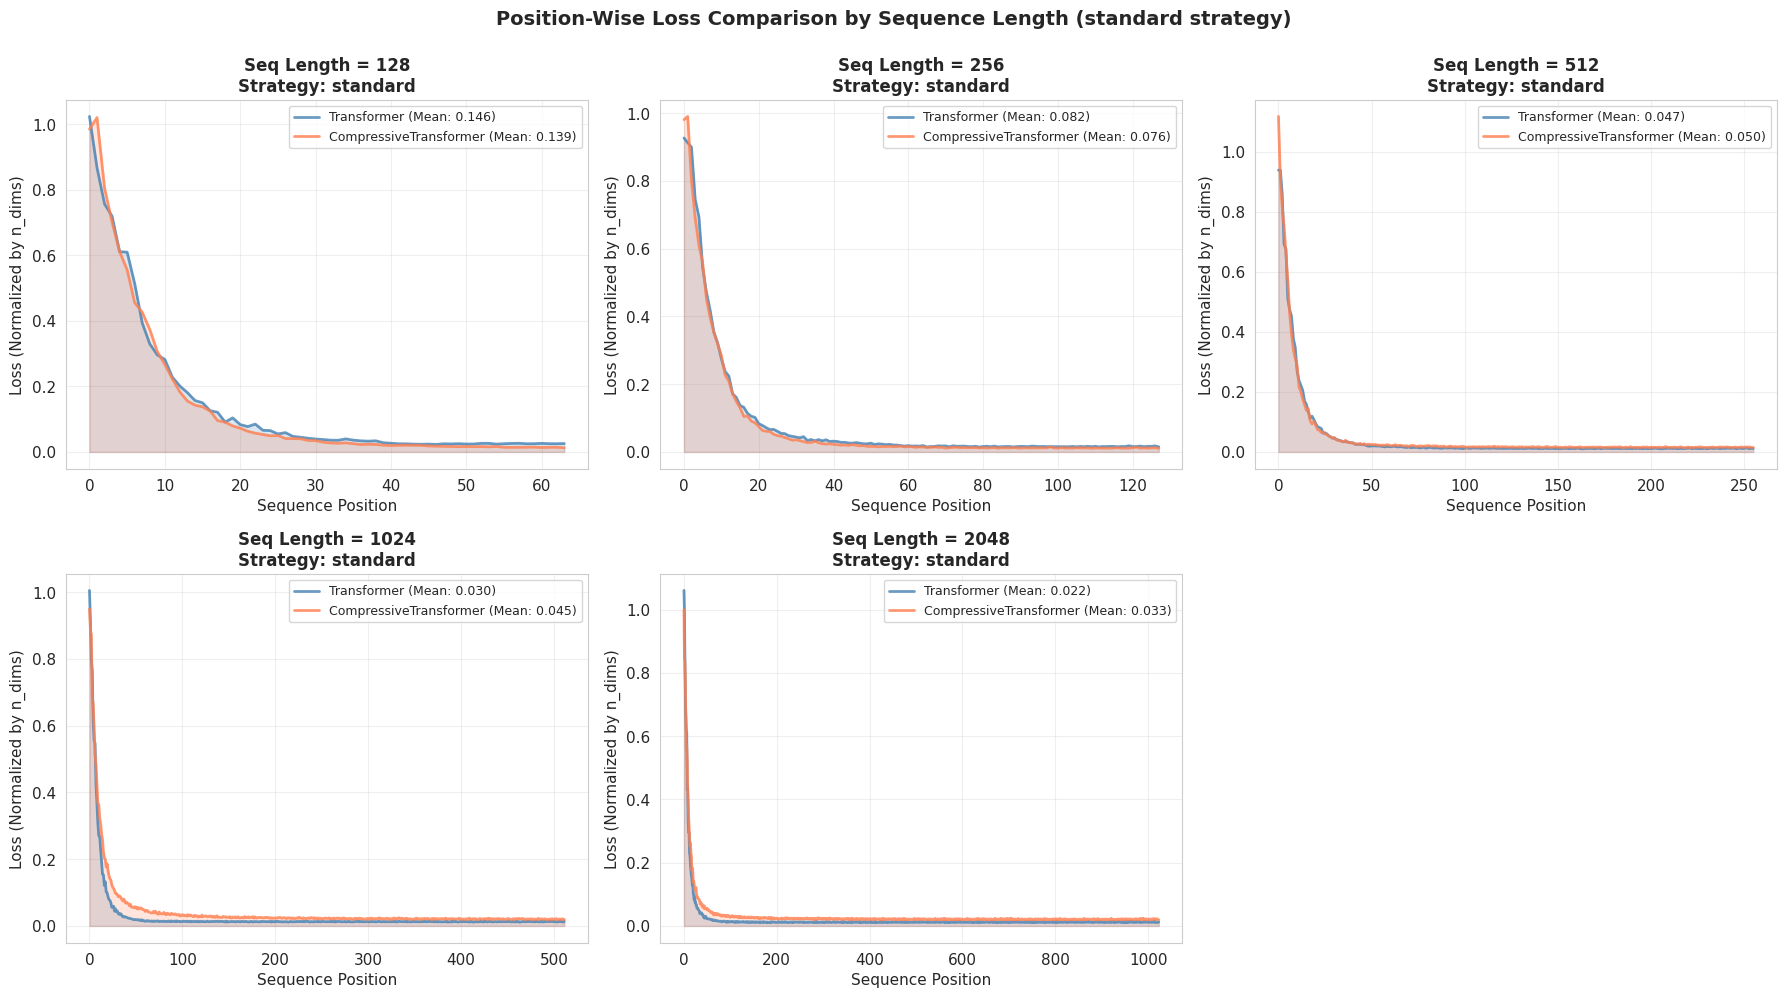

In [6]:
# Plot position-wise loss grouped by sequence length
# Compare Transformer and CompressiveTransformer on the same plot for each sequence length
# Using DEFAULT_STRATEGY (default: 'standard')

# Group available runs by sequence length
seq_lengths_with_data = set()
for (model_type, seq_len), runs in all_runs.items():
    if any(r['has_metrics'] for r in runs):
        seq_lengths_with_data.add(seq_len)

if seq_lengths_with_data:
    # Sort sequence lengths
    sorted_seq_lengths = sorted(seq_lengths_with_data)
    n_plots = len(sorted_seq_lengths)
    cols = min(3, n_plots)
    rows = (n_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Identify model type names
    transformer_name = None
    compressive_name = None
    for model_type in df_performance['model_type'].unique() if len(df_performance) > 0 else []:
        if 'transformer' in model_type.lower() and 'compressive' not in model_type.lower():
            transformer_name = model_type
        elif 'compressive' in model_type.lower():
            compressive_name = model_type
    
    for idx, seq_len in enumerate(sorted_seq_lengths):
        ax = axes[idx]
        has_data = False
        
        # Plot Transformer if available
        if transformer_name and (transformer_name, seq_len) in all_runs:
            trans_runs = all_runs[(transformer_name, seq_len)]
            trans_run = next((r for r in trans_runs if r['has_metrics']), None)
            if trans_run and trans_run['metrics']:
                # Get n_dims for normalization
                n_dims = 10  # default
                if trans_run['has_config'] and trans_run['config']:
                    n_dims = trans_run['config'].get('model', {}).get('n_dims', 10)
                
                trans_losses = get_strategy_losses(trans_run['metrics'], DEFAULT_STRATEGY)
                if trans_losses is not None:
                    normalized_losses = trans_losses / n_dims
                    positions = np.arange(len(normalized_losses))
                    ax.plot(positions, normalized_losses, linewidth=2, alpha=0.8, 
                           color='steelblue', label=f'Transformer (Mean: {np.mean(normalized_losses):.3f})')
                    ax.fill_between(positions, normalized_losses, alpha=0.2, color='steelblue')
                    has_data = True
        
        # Plot CompressiveTransformer if available
        if compressive_name and (compressive_name, seq_len) in all_runs:
            comp_runs = all_runs[(compressive_name, seq_len)]
            comp_run = next((r for r in comp_runs if r['has_metrics']), None)
            if comp_run and comp_run['metrics']:
                # Get n_dims for normalization
                n_dims = 10  # default
                if comp_run['has_config'] and comp_run['config']:
                    n_dims = comp_run['config'].get('model', {}).get('n_dims', 10)
                
                comp_losses = get_strategy_losses(comp_run['metrics'], DEFAULT_STRATEGY)
                if comp_losses is not None:
                    normalized_losses = comp_losses / n_dims
                    positions = np.arange(len(normalized_losses))
                    ax.plot(positions, normalized_losses, linewidth=2, alpha=0.8, 
                           color='coral', label=f'CompressiveTransformer (Mean: {np.mean(normalized_losses):.3f})')
                    ax.fill_between(positions, normalized_losses, alpha=0.2, color='coral')
                    has_data = True
        
        if has_data:
            ax.set_xlabel('Sequence Position', fontsize=11)
            ax.set_ylabel('Loss (Normalized by n_dims)', fontsize=11)
            ax.set_title(f'Seq Length = {seq_len}\nStrategy: {DEFAULT_STRATEGY}', 
                       fontsize=12, fontweight='bold')
            ax.legend(fontsize=9, loc='best')
            ax.grid(True, alpha=0.3)
        else:
            ax.axis('off')
    
    # Hide unused subplots
    for idx in range(len(sorted_seq_lengths), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Position-Wise Loss Comparison by Sequence Length ({DEFAULT_STRATEGY} strategy)', 
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print("No position-wise data available.")


## 5. Model Comparison Table


In [ ]:
if len(df_performance) > 0:
    # Get actual model types from the data
    actual_model_types = df_performance['model_type'].unique()
    print(f"Available model types: {actual_model_types}")
    
    # Map to standard names for comparison
    # Try to identify transformer and compressive models
    transformer_name = None
    compressive_name = None
    
    for model_type in actual_model_types:
        if 'transformer' in model_type.lower() and 'compressive' not in model_type.lower():
            transformer_name = model_type
        elif 'compressive' in model_type.lower():
            compressive_name = model_type
    
    # Create comparison table
    comparison_rows = []
    
    for seq_len in SEQUENCE_LENGTHS:
        trans_data = df_performance[
            (df_performance['model_type'] == transformer_name) & 
            (df_performance['sequence_length'] == seq_len)
        ] if transformer_name else pd.DataFrame()
        
        comp_data = df_performance[
            (df_performance['model_type'] == compressive_name) & 
            (df_performance['sequence_length'] == seq_len)
        ] if compressive_name else pd.DataFrame()
        
        trans_loss = trans_data.iloc[0]['mean_loss'] if len(trans_data) > 0 else None
        comp_loss = comp_data.iloc[0]['mean_loss'] if len(comp_data) > 0 else None
        
        improvement = None
        better_model = None
        
        if trans_loss is not None and comp_loss is not None:
            if trans_loss > 0:
                improvement = ((trans_loss - comp_loss) / trans_loss) * 100
            better_model = 'CompressiveTransformer' if comp_loss < trans_loss else 'Transformer'
        elif trans_loss is not None:
            better_model = 'Transformer (only)'
        elif comp_loss is not None:
            better_model = 'CompressiveTransformer (only)'
        
        comparison_rows.append({
            'Sequence Length': seq_len,
            'Transformer Loss': f'{trans_loss:.4f}' if trans_loss is not None else 'N/A',
            'CompressiveTransformer Loss': f'{comp_loss:.4f}' if comp_loss is not None else 'N/A',
            'Improvement %': f'{improvement:.2f}%' if improvement is not None else 'N/A',
            'Better Model': better_model if better_model else 'N/A'
        })
    
    df_comparison = pd.DataFrame(comparison_rows)
    
    print("\nModel Comparison by Sequence Length")
    print("=" * 80)
    print(df_comparison.to_string(index=False))
    
    # Save to CSV
    output_file = Path('experiment2_comparison.csv')
    df_comparison.to_csv(output_file, index=False)
    print(f"\nComparison table saved to: {output_file}")
else:
    print("No data available for comparison.")


## 6. Evaluation Strategy Analysis (Optional)

**Note:** This section is only relevant if `ANALYZE_OTHER_STRATEGIES = True` in the configuration cell above.

To analyze other evaluation strategies, set `ANALYZE_OTHER_STRATEGIES = True` and re-run the notebook.


In [ ]:
# # Optional: Compare different evaluation strategies
# # This cell will only show meaningful results if ANALYZE_OTHER_STRATEGIES = True

# if ANALYZE_OTHER_STRATEGIES and len(df_performance) > 0:
#     # Get all available strategies from the first run's metrics
#     first_run = None
#     for (model_type, seq_len), runs in all_runs.items():
#         for run in runs:
#             if run['has_metrics']:
#                 first_run = run
#                 break
#         if first_run:
#             break
    
#     if first_run and first_run['metrics']:
#         available_strategies = list(first_run['metrics'].keys())
#         print(f"Available evaluation strategies: {available_strategies}")
        
#         # Compare strategies for each model/sequence combination
#         strategy_comparison = []
        
#         for (model_type, seq_len), runs in all_runs.items():
#             selected_run = next((r for r in runs if r['has_metrics']), None)
#             if selected_run and selected_run['metrics']:
#                 for strategy in available_strategies:
#                     losses = get_strategy_losses(selected_run['metrics'], strategy)
#                     if losses is not None:
#                         strategy_comparison.append({
#                             'model_type': model_type,
#                             'sequence_length': seq_len,
#                             'strategy': strategy,
#                             'mean_loss': np.mean(losses),
#                             'std_loss': np.std(losses)
#                         })
        
#         if strategy_comparison:
#             df_strategy = pd.DataFrame(strategy_comparison)
            
#             # Plot strategy comparison
#             fig, ax = plt.subplots(figsize=(14, 8))
            
#             pivot_data = df_strategy.pivot_table(
#                 values='mean_loss',
#                 index=['model_type', 'sequence_length'],
#                 columns='strategy',
#                 aggfunc='mean'
#             )
            
#             pivot_data.plot(kind='bar', ax=ax, width=0.8)
#             ax.set_xlabel('Model Type & Sequence Length', fontsize=12)
#             ax.set_ylabel('Mean Loss', fontsize=12)
#             ax.set_title('Performance Across Different Evaluation Strategies', fontsize=13, fontweight='bold')
#             ax.legend(title='Evaluation Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
#             ax.grid(axis='y', alpha=0.3)
            
#             # Rotate x-axis labels
#             labels = [f"{idx[0]}\nseq={idx[1]}" for idx in pivot_data.index]
#             ax.set_xticklabels(labels, rotation=45, ha='right')
            
#             plt.tight_layout()
#             plt.show()
            
#             print("\nStrategy Performance Summary:")
#             print("-" * 80)
#             print(df_strategy.groupby('strategy')['mean_loss'].agg(['mean', 'std', 'min', 'max']).to_string())
#         else:
#             print("No strategy comparison data available.")
#     else:
#         print("No metrics data found for strategy comparison.")
# else:
#     print(f"Strategy comparison is disabled. Set ANALYZE_OTHER_STRATEGIES = True to enable.")
#     print(f"Current setting: ANALYZE_OTHER_STRATEGIES = {ANALYZE_OTHER_STRATEGIES}")


# Experiment 3: Memory Compression Analysis

This notebook analyzes the ICL performance of CompressiveTransformer models with different memory-to-context ratios (1:1, 1:4, 1:8).

## Objectives
- Compare ICL performance across different memory-to-context ratios (1:1, 1:4, 1:8)
- Quantify how compressive memory affects ICL performance
- Identify effective configurations balancing accuracy and efficiency
- **Default: Analysis focuses on `standard` evaluation strategy only**


In [7]:
# Experiment 3 Configuration
MEMORY_RATIOS = ['1:1', '1:4', '1:8']  # Memory-to-context ratios
MEMORY_RATIO_VALUES = {'1:1': 1, '1:4': 4, '1:8': 8}  # cmem_ratio values
OUTPUTS_DIR_EXP3 = (Path("..") / "outputs").resolve()

# Analysis configuration
ANALYZE_OTHER_STRATEGIES_EXP3 = False  # Default: False (only analyze 'standard' strategy)
DEFAULT_STRATEGY_EXP3 = 'standard'  # Default strategy for main analysis

print("Experiment 3: Memory Compression Analysis")
print("=" * 60)
print(f"Memory-to-context ratios to analyze: {MEMORY_RATIOS}")
print(f"Outputs directory: {OUTPUTS_DIR_EXP3.absolute()}")
print(f"\nAnalysis Configuration:")
print(f"  Default strategy: {DEFAULT_STRATEGY_EXP3}")
print(f"  Analyze other strategies: {ANALYZE_OTHER_STRATEGIES_EXP3}")


Experiment 3: Memory Compression Analysis
Memory-to-context ratios to analyze: ['1:1', '1:4', '1:8']
Outputs directory: /accounts/grad/xi_cheng1017/CS282_Final_Project/outputs

Analysis Configuration:
  Default strategy: standard
  Analyze other strategies: False


## 1. Data Loading and Discovery


In [8]:
def extract_memory_ratio_info(run_dir):
    """
    Parser for run directory names to extract memory compression ratio.
    Supports:
      id_comp_memratio_1_1_xxx
      id_comp_memratio_1_4_xxx
      id_comp_memratio_1_8_xxx
      id_comp_seq512_xxx (if cmem_ratio=4, treat as 1:4)
    """
    name = run_dir.name

    if not name.startswith("id_"):
        return None, None

    run_id = name.replace("id_", "", 1)
    parts = run_id.split("_")

    # Check for memory ratio pattern: comp_memratio_1_1, comp_memratio_1_4, comp_memratio_1_8
    if len(parts) >= 4 and parts[0] == "comp" and parts[1] == "memratio":
        ratio_str = f"{parts[2]}:{parts[3]}"
        if ratio_str in MEMORY_RATIOS:
            return ratio_str, run_id
    
    # Check for seq512 pattern: comp_seq512_xxx
    # If cmem_ratio=4, treat it as memratio=1:4 (since seq512 uses cmem_ratio=4)
    if len(parts) >= 2 and parts[0] == "comp" and parts[1].startswith("seq"):
        seq_len = parts[1][3:]  # Extract number from "seq512"
        if seq_len == "512":
            # Check config file to verify cmem_ratio
            config_file = run_dir / "config.yaml"
            if config_file.exists():
                try:
                    with open(config_file, 'r') as f:
                        config = yaml.safe_load(f)
                        model_config = config.get('model', {})
                        cmem_ratio = model_config.get('cmem_ratio')
                        # If cmem_ratio=4, this is equivalent to memratio=1:4
                        if cmem_ratio == 4:
                            return "1:4", run_id
                except Exception as e:
                    # If config read fails, skip this directory
                    pass

    return None, None

# Discover all memory compression experiment runs
all_runs_exp3 = {}
seq512_used_for_1_4 = False  # Track if seq512 is being used for 1:4
if OUTPUTS_DIR_EXP3.exists():
    for item in OUTPUTS_DIR_EXP3.iterdir():
        if item.is_dir() and item.name.startswith("id_"):
            ratio, run_id = extract_memory_ratio_info(item)
            if ratio:
                if ratio not in all_runs_exp3:
                    all_runs_exp3[ratio] = []
                run_data = load_run_data(item)
                # Check if this is a seq512 run being used for 1:4
                if ratio == "1:4" and "seq512" in run_id:
                    seq512_used_for_1_4 = True
                all_runs_exp3[ratio].append({
                    'run_id': run_id,
                    'run_dir': item,
                    'memory_ratio': ratio,
                    **run_data
                })

print(f"\nFound {len(all_runs_exp3)} unique memory compression configurations")
if seq512_used_for_1_4:
    print("Note: Using seq512 results for memratio=1:4 (same configuration: cmem_ratio=4)")
print("\nAvailable experiments:")
print("-" * 60)
for ratio in MEMORY_RATIOS:
    if ratio in all_runs_exp3:
        runs = all_runs_exp3[ratio]
        has_data = any(r['has_metrics'] for r in runs)
        status = "✓" if has_data else "✗"
        run_sources = []
        for r in runs:
            if "seq512" in r['run_id']:
                run_sources.append("seq512")
            elif "memratio" in r['run_id']:
                run_sources.append("memratio")
        source_info = f" ({', '.join(set(run_sources))})" if run_sources else ""
        print(f"{status} Memory Ratio {ratio:>4s}: {len(runs)} run(s){source_info}")
    else:
        print(f"✗ Memory Ratio {ratio:>4s}: 0 run(s)")



Found 3 unique memory compression configurations
Note: Using seq512 results for memratio=1:4 (same configuration: cmem_ratio=4)

Available experiments:
------------------------------------------------------------
✓ Memory Ratio  1:1: 1 run(s) (memratio)
✓ Memory Ratio  1:4: 1 run(s) (seq512)
✓ Memory Ratio  1:8: 1 run(s) (memratio)


## 2. Extract Performance Metrics


In [9]:
# Extract performance data for all memory compression runs
performance_data_exp3 = []

for ratio in MEMORY_RATIOS:
    if ratio not in all_runs_exp3:
        continue
    
    runs = all_runs_exp3[ratio]
    # Use the run with metrics if available
    selected_run = None
    for run in runs:
        if run['has_metrics']:
            selected_run = run
            break
    
    if selected_run and selected_run['has_metrics']:
        # Get n_dims from config if available
        n_dims = 10  # default
        if selected_run['has_config'] and selected_run['config']:
            model_config = selected_run['config'].get('model', {})
            n_dims = model_config.get('n_dims', 10)
        
        metrics = compute_performance_metrics(
            selected_run['metrics'], 
            strategy=DEFAULT_STRATEGY_EXP3,
            include_other_strategies=ANALYZE_OTHER_STRATEGIES_EXP3,
            n_dims=n_dims
        )
        if metrics:
            # Extract cmem_ratio from config if available
            cmem_ratio = None
            if selected_run['has_config'] and selected_run['config']:
                model_config = selected_run['config'].get('model', {})
                cmem_ratio = model_config.get('cmem_ratio', MEMORY_RATIO_VALUES.get(ratio))
            
            performance_data_exp3.append({
                'memory_ratio': ratio,
                'cmem_ratio': cmem_ratio if cmem_ratio else MEMORY_RATIO_VALUES.get(ratio),
                'run_id': selected_run['run_id'],
                'n_dims': n_dims,  # Store n_dims for reference
                **metrics
            })

# Create DataFrame
df_performance_exp3 = pd.DataFrame(performance_data_exp3)

if len(df_performance_exp3) > 0:
    print(f"\nLoaded performance data for {len(df_performance_exp3)} memory compression experiments")
    print(f"Analysis strategy: {DEFAULT_STRATEGY_EXP3}")
    print("Note: Loss values are normalized by n_dims (loss/n_dims)")
    print("Note: Sequence length = n_points * 2 (each point is a pair x,y)")
    print("\nPerformance Summary:")
    print("-" * 80)
    print(df_performance_exp3[['memory_ratio', 'cmem_ratio', 'sequence_length', 'n_points', 'mean_loss', 'std_loss']].to_string(index=False))
else:
    print("\nNo performance data found. Please ensure experiments have been run and evaluated.")



Loaded performance data for 3 memory compression experiments
Analysis strategy: standard
Note: Loss values are normalized by n_dims (loss/n_dims)
Note: Sequence length = n_points * 2 (each point is a pair x,y)

Performance Summary:
--------------------------------------------------------------------------------
memory_ratio  cmem_ratio  sequence_length  n_points  mean_loss  std_loss
         1:1           1              512       256   0.049456  0.129244
         1:4           4              512       256   0.049716  0.131632
         1:8           8              512       256   0.046149  0.126879


## 3. Memory Compression Ratio Analysis


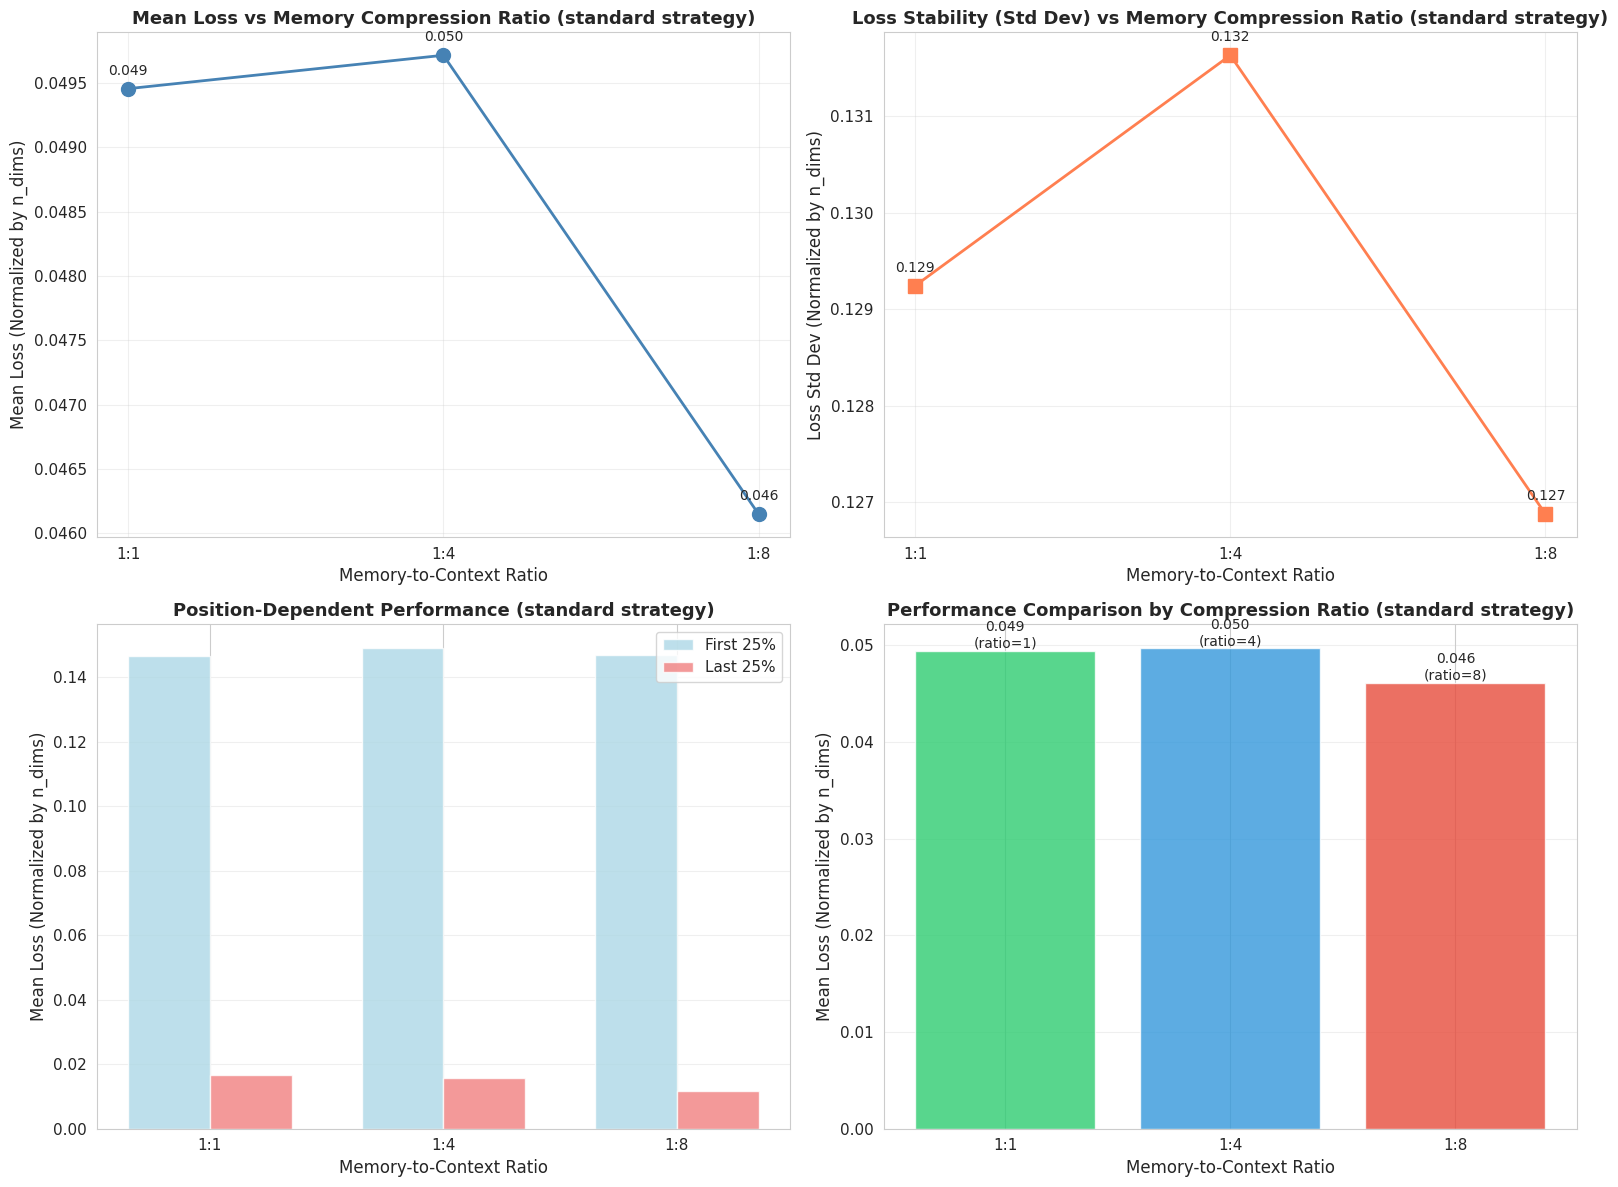

In [10]:
if len(df_performance_exp3) > 0:
    # Sort by cmem_ratio for consistent ordering
    df_sorted = df_performance_exp3.sort_values('cmem_ratio')
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Mean loss vs memory compression ratio
    ax1 = axes[0, 0]
    ratios_ordered = df_sorted['memory_ratio'].values
    mean_losses = df_sorted['mean_loss'].values
    ax1.plot(range(len(ratios_ordered)), mean_losses, 
            marker='o', linewidth=2, markersize=10, color='steelblue')
    ax1.set_xticks(range(len(ratios_ordered)))
    ax1.set_xticklabels(ratios_ordered)
    ax1.set_xlabel('Memory-to-Context Ratio', fontsize=12)
    ax1.set_ylabel('Mean Loss (Normalized by n_dims)', fontsize=12)
    ax1.set_title(f'Mean Loss vs Memory Compression Ratio ({DEFAULT_STRATEGY_EXP3} strategy)', 
                 fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    # Add value labels on points
    for i, (ratio, loss) in enumerate(zip(ratios_ordered, mean_losses)):
        ax1.annotate(f'{loss:.3f}', (i, loss), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=10)
    
    # Plot 2: Loss stability (std) vs memory compression ratio
    ax2 = axes[0, 1]
    std_losses = df_sorted['std_loss'].values
    ax2.plot(range(len(ratios_ordered)), std_losses, 
            marker='s', linewidth=2, markersize=10, color='coral')
    ax2.set_xticks(range(len(ratios_ordered)))
    ax2.set_xticklabels(ratios_ordered)
    ax2.set_xlabel('Memory-to-Context Ratio', fontsize=12)
    ax2.set_ylabel('Loss Std Dev (Normalized by n_dims)', fontsize=12)
    ax2.set_title(f'Loss Stability (Std Dev) vs Memory Compression Ratio ({DEFAULT_STRATEGY_EXP3} strategy)', 
                 fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    # Add value labels on points
    for i, (ratio, std) in enumerate(zip(ratios_ordered, std_losses)):
        ax2.annotate(f'{std:.3f}', (i, std), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=10)
    
    # Plot 3: Position-dependent performance (first vs last quarter)
    ax3 = axes[1, 0]
    first_quarter = df_sorted['first_quarter_mean'].values
    last_quarter = df_sorted['last_quarter_mean'].values
    x_pos = range(len(ratios_ordered))
    width = 0.35
    ax3.bar([x - width/2 for x in x_pos], first_quarter, width, 
           label='First 25%', alpha=0.8, color='lightblue')
    ax3.bar([x + width/2 for x in x_pos], last_quarter, width, 
           label='Last 25%', alpha=0.8, color='lightcoral')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(ratios_ordered)
    ax3.set_xlabel('Memory-to-Context Ratio', fontsize=12)
    ax3.set_ylabel('Mean Loss (Normalized by n_dims)', fontsize=12)
    ax3.set_title(f'Position-Dependent Performance ({DEFAULT_STRATEGY_EXP3} strategy)', 
                 fontsize=13, fontweight='bold')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # Plot 4: Comparison bar chart with efficiency metrics
    ax4 = axes[1, 1]
    # Calculate compression efficiency (lower cmem_ratio = less compression = more memory)
    compression_efficiency = df_sorted['cmem_ratio'].values  # Higher = more compressed
    mean_losses_bar = df_sorted['mean_loss'].values
    
    bars = ax4.bar(range(len(ratios_ordered)), mean_losses_bar, 
                  alpha=0.8, color=['#2ecc71', '#3498db', '#e74c3c'][:len(ratios_ordered)])
    ax4.set_xticks(range(len(ratios_ordered)))
    ax4.set_xticklabels(ratios_ordered)
    ax4.set_xlabel('Memory-to-Context Ratio', fontsize=12)
    ax4.set_ylabel('Mean Loss (Normalized by n_dims)', fontsize=12)
    ax4.set_title(f'Performance Comparison by Compression Ratio ({DEFAULT_STRATEGY_EXP3} strategy)', 
                 fontsize=13, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    # Add value labels on bars
    for i, (bar, loss) in enumerate(zip(bars, mean_losses_bar)):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{loss:.3f}\n(ratio={compression_efficiency[i]})',
                ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting. Please run experiments first.")


## 4. Detailed Position-Wise Analysis


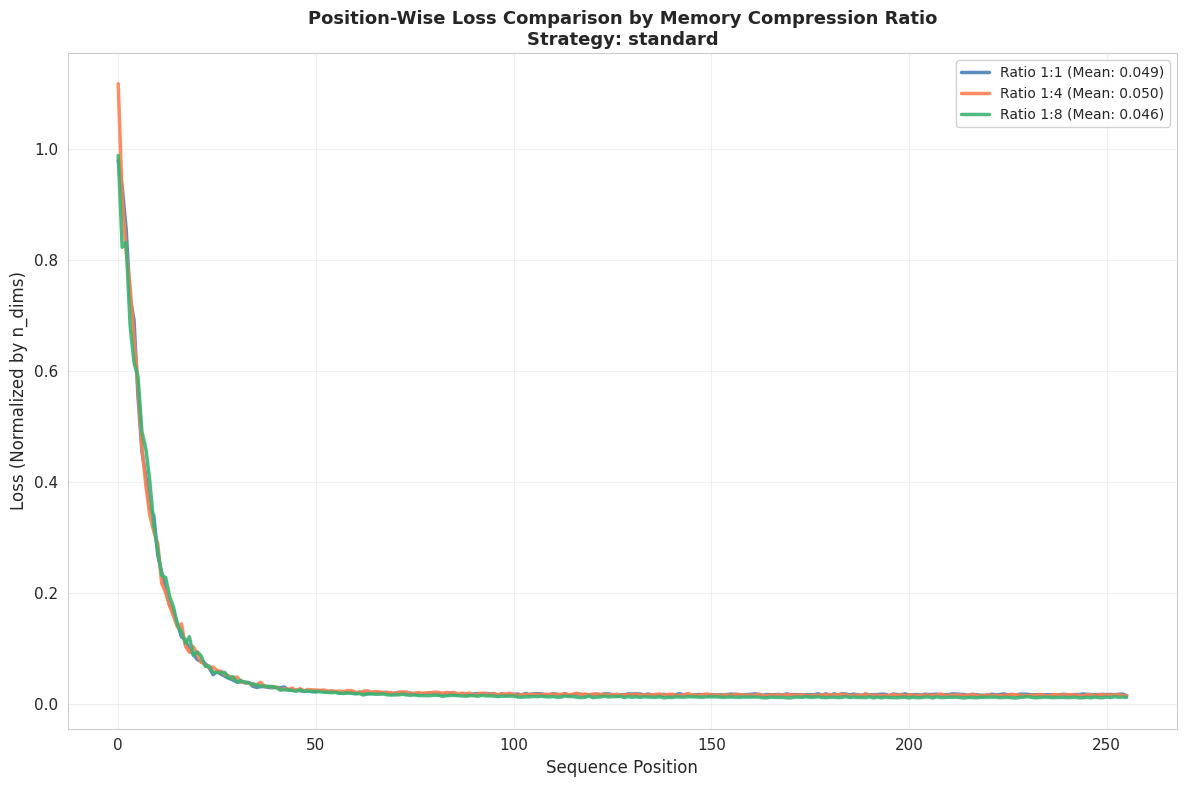

In [12]:
# Plot position-wise loss for all memory compression ratios on a single plot
available_ratios = [ratio for ratio in MEMORY_RATIOS if ratio in all_runs_exp3 
                   and any(r['has_metrics'] for r in all_runs_exp3[ratio])]

if available_ratios:
    # Create a single figure with one subplot
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Define colors for different ratios
    colors = ['steelblue', 'coral', 'mediumseagreen', 'gold', 'orchid']
    
    # Sort ratios by cmem_ratio value for consistent ordering
    sorted_ratios = sorted(available_ratios, key=lambda x: MEMORY_RATIO_VALUES.get(x, 0))
    
    for idx, ratio in enumerate(sorted_ratios):
        runs = all_runs_exp3[ratio]
        selected_run = next((r for r in runs if r['has_metrics']), None)
        
        if selected_run and selected_run['metrics']:
            # Get n_dims for normalization
            n_dims = 10  # default
            if selected_run['has_config'] and selected_run['config']:
                n_dims = selected_run['config'].get('model', {}).get('n_dims', 10)
            
            losses = get_strategy_losses(selected_run['metrics'], DEFAULT_STRATEGY_EXP3)
            if losses is not None:
                # Normalize losses by n_dims
                normalized_losses = losses / n_dims
                positions = np.arange(len(normalized_losses))
                color = colors[idx % len(colors)]
                ax.plot(positions, normalized_losses, linewidth=2.5, alpha=0.9, 
                       color=color, label=f'Ratio {ratio} (Mean: {np.mean(normalized_losses):.3f})')
    
    ax.set_xlabel('Sequence Position', fontsize=12)
    ax.set_ylabel('Loss (Normalized by n_dims)', fontsize=12)
    ax.set_title(f'Position-Wise Loss Comparison by Memory Compression Ratio\nStrategy: {DEFAULT_STRATEGY_EXP3}', 
               fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No position-wise data available.")


## 5. Efficiency vs Accuracy Trade-off Analysis


In [ ]:
if len(df_performance_exp3) > 0:
    # Calculate efficiency metrics
    # Compression ratio: higher cmem_ratio = more compression = less memory used
    # Efficiency: inverse of compression ratio (normalized)
    df_sorted = df_performance_exp3.sort_values('cmem_ratio')
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Accuracy (inverse of loss) vs Compression Ratio
    ax1 = axes[0]
    compression_ratios = df_sorted['cmem_ratio'].values
    mean_losses = df_sorted['mean_loss'].values
    # Use inverse loss as a proxy for accuracy
    accuracy_proxy = 1.0 / (mean_losses + 1e-6)  # Add small epsilon to avoid division by zero
    
    ax1.scatter(compression_ratios, accuracy_proxy, s=200, alpha=0.7, 
               c=range(len(compression_ratios)), cmap='viridis')
    for i, (ratio, acc, mem_ratio) in enumerate(zip(compression_ratios, accuracy_proxy, df_sorted['memory_ratio'].values)):
        ax1.annotate(f'{mem_ratio}', (ratio, acc), textcoords="offset points", 
                    xytext=(0,15), ha='center', fontsize=11, fontweight='bold')
    
    ax1.set_xlabel('Compression Ratio (cmem_ratio)', fontsize=12)
    ax1.set_ylabel('Accuracy Proxy (1 / Loss)', fontsize=12)
    ax1.set_title('Accuracy vs Compression Ratio', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log', base=2)
    
    # Plot 2: Loss vs Compression Ratio with efficiency annotation
    ax2 = axes[1]
    colors_map = {'1:1': '#2ecc71', '1:4': '#3498db', '1:8': '#e74c3c'}
    for ratio in df_sorted['memory_ratio'].values:
        data = df_sorted[df_sorted['memory_ratio'] == ratio]
        if len(data) > 0:
            ax2.scatter(data['cmem_ratio'].values, data['mean_loss'].values, 
                       s=200, alpha=0.7, label=f'Ratio {ratio}', 
                       color=colors_map.get(ratio, 'gray'))
    
    ax2.set_xlabel('Compression Ratio (cmem_ratio)', fontsize=12)
    ax2.set_ylabel('Mean Loss', fontsize=12)
    ax2.set_title('Performance vs Compression Ratio Trade-off', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log', base=2)
    
    # Add annotations for efficiency
    for _, row in df_sorted.iterrows():
        memory_saved = (1 - 1/row['cmem_ratio']) * 100  # Percentage of memory saved
        ax2.annotate(f"{memory_saved:.1f}% saved", 
                    (row['cmem_ratio'], row['mean_loss']),
                    textcoords="offset points", xytext=(10,10), 
                    ha='left', fontsize=9, alpha=0.7,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    # Print efficiency summary
    print("\nEfficiency vs Accuracy Summary:")
    print("=" * 80)
    for _, row in df_sorted.iterrows():
        memory_saved = (1 - 1/row['cmem_ratio']) * 100
        print(f"Ratio {row['memory_ratio']:>4s} (cmem_ratio={row['cmem_ratio']:>2.0f}): "
              f"Loss={row['mean_loss']:.4f}, Memory Saved={memory_saved:>5.1f}%")
else:
    print("No data available for efficiency analysis.")


## 6. Comparison Table


In [ ]:
if len(df_performance_exp3) > 0:
    df_sorted = df_performance_exp3.sort_values('cmem_ratio')
    
    # Create comparison table
    comparison_rows = []
    baseline_loss = None
    
    for _, row in df_sorted.iterrows():
        memory_saved = (1 - 1/row['cmem_ratio']) * 100
        compression_factor = row['cmem_ratio']
        
        # Calculate relative performance (compared to 1:1 if available)
        if baseline_loss is None:
            baseline_loss = row['mean_loss']
            relative_performance = 0.0
        else:
            relative_performance = ((row['mean_loss'] - baseline_loss) / baseline_loss) * 100
        
        comparison_rows.append({
            'Memory Ratio': row['memory_ratio'],
            'Compression Ratio': f"{compression_factor:.0f}",
            'Mean Loss': f'{row["mean_loss"]:.4f}',
            'Std Loss': f'{row["std_loss"]:.4f}',
            'Memory Saved %': f'{memory_saved:.1f}%',
            'Relative Performance %': f'{relative_performance:+.2f}%',
            'First 25% Loss': f'{row["first_quarter_mean"]:.4f}',
            'Last 25% Loss': f'{row["last_quarter_mean"]:.4f}'
        })
    
    df_comparison_exp3 = pd.DataFrame(comparison_rows)
    
    print("\nMemory Compression Comparison Table")
    print("=" * 120)
    print(df_comparison_exp3.to_string(index=False))
    
    # Save to CSV
    output_file = Path('experiment3_comparison.csv')
    df_comparison_exp3.to_csv(output_file, index=False)
    print(f"\nComparison table saved to: {output_file}")
else:
    print("No data available for comparison.")


## 7. Key Findings and Summary


In [ ]:
if len(df_performance_exp3) > 0:
    df_sorted = df_performance_exp3.sort_values('cmem_ratio')
    
    print("\n" + "=" * 80)
    print("EXPERIMENT 3: MEMORY COMPRESSION - KEY FINDINGS")
    print("=" * 80)
    
    # Find best performing configuration
    best_idx = df_sorted['mean_loss'].idxmin()
    best_config = df_sorted.loc[best_idx]
    
    print(f"\n1. Best Performing Configuration:")
    print(f"   Memory Ratio: {best_config['memory_ratio']}")
    print(f"   Compression Ratio: {best_config['cmem_ratio']:.0f}")
    print(f"   Mean Loss: {best_config['mean_loss']:.4f}")
    print(f"   Memory Saved: {(1 - 1/best_config['cmem_ratio']) * 100:.1f}%")
    
    # Compare all configurations
    print(f"\n2. Performance Across Configurations:")
    for _, row in df_sorted.iterrows():
        memory_saved = (1 - 1/row['cmem_ratio']) * 100
        print(f"   Ratio {row['memory_ratio']:>4s}: Loss={row['mean_loss']:.4f}, "
              f"Std={row['std_loss']:.4f}, Memory Saved={memory_saved:>5.1f}%")
    
    # Calculate efficiency metrics
    print(f"\n3. Efficiency Analysis:")
    losses = df_sorted['mean_loss'].values
    compression_ratios = df_sorted['cmem_ratio'].values
    
    # Performance degradation per compression unit
    if len(losses) > 1:
        performance_degradation = (losses[-1] - losses[0]) / (compression_ratios[-1] - compression_ratios[0])
        print(f"   Performance degradation per compression unit: {performance_degradation:.4f}")
    
    # Best efficiency (lowest loss per memory saved)
    efficiency_scores = []
    for _, row in df_sorted.iterrows():
        memory_saved = (1 - 1/row['cmem_ratio']) * 100
        if memory_saved > 0:
            efficiency = row['mean_loss'] / memory_saved  # Lower is better
        else:
            efficiency = row['mean_loss']
        efficiency_scores.append((row['memory_ratio'], efficiency))
    
    best_efficiency = min(efficiency_scores, key=lambda x: x[1])
    print(f"   Best efficiency (lowest loss per % memory saved): {best_efficiency[0]} "
          f"(efficiency score: {best_efficiency[1]:.4f})")
    
    print("\n" + "=" * 80)
else:
    print("No data available for summary.")
